# LASSO / Elastic Net — Iteration of the Linear Approach

**BioITWorld talk — Notebook 2 of 3.**

If the "pedestrian" linear model is the strawman in Notebook 1, LASSO is the
honest steel-man: regularized linear regression that does feature selection
on a small, collinear, multi-study dataset. It is exactly the kind of model
Richard Scheuermann's argument *should* be evaluated against.

**What this notebook does:**

1. Local LASSO per study (matches the existing per-study Ridge / RF / CNN structure).
2. Federated LASSO via median + IQR aggregation of per-study coefficients.
3. Pooled LASSO with Study one-hot dummies so Study effects don't leak into
   autoantibody coefficients.
4. Elastic Net (full L1/L2 grid) for the same protocols.
5. Stability selection (Meinshausen-Bühlmann subsampling) — which features
   are picked *consistently*?
6. Bootstrap 95% CIs on coefficients.
7. Sparsity-vs-accuracy trade-off plot.

Run on **both feature panels** — Panel A (legacy 9-feature N=150) and Panel B
(Jeff-extended ~23-feature N=98). The Jeff panel is where LASSO selection
becomes substantively interesting: does BMI / disease duration / treatment
cohort survive selection?

**Outputs:** `results/lasso_*.csv` and `figures/lasso_*.pdf`.


## 1. Setup

In [1]:
from __future__ import annotations
import sys, os, warnings, json
from pathlib import Path
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path.cwd()
if (REPO / "src").exists():
    sys.path.insert(0, str(REPO / "src"))
elif (REPO.parent / "src").exists():
    REPO = REPO.parent
    sys.path.insert(0, str(REPO / "src"))
os.chdir(REPO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, ElasticNetCV, Lasso, ElasticNet
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

import oadr_data as od

RNG_SEED = 42
N_BOOT = 1000
N_FOLDS = 5
N_STAB = 200       # subsamples for stability selection
np.random.seed(RNG_SEED)

(REPO / "results").mkdir(exist_ok=True)
(REPO / "figures").mkdir(exist_ok=True)
print("Repo:", REPO)


Repo: /Users/adeslatt/Scitechcon Dropbox/Anne DeslattesMays/projects/oadr-autoantibody


### A note on `src/oadr_data.py`

`oadr_data` is the single utility file that resolves all the per-study
data quirks (column-name typos, `IA_2ic` ↔ `IA2IC` mismatches, age-group
recoding, varying autoantibody panels per study, Jeff-extended panel
merging). Keeping that complexity in one place lets each notebook stay
focused on the science. Open `src/oadr_data.py` if you want to read the
cleanup line by line.

- `load_panel_a_all()` → 150 subjects × 9 features (legacy 5-autoantibody +
  age-group + sex panel), matching the input every existing CNN/Ridge/RF
  notebook saw.
- `load_panel_b_all()` → 98 subjects × 23 features (Jeff-extended panel:
  3 of the 4 supervised studies, with BMI, exact age, race, ethnicity,
  treatment cohort, disease duration since T1D diagnosis added).


In [2]:
A = od.load_panel_a_all()
Xa, ya, fa = od.panel_a_design_matrix(A)
print(f"Panel A: N={len(A)} features={len(fa)}")
print(A.groupby("Study").size().to_string())

B = od.load_panel_b_all()
Xb, yb, fb = od.panel_b_design_matrix(B)
print(f"\nPanel B: N={len(B)} features={len(fb)}")
print(B.groupby("Study").size().to_string())


Panel A: N=150 features=9
Study
SDY1737    16
SDY524     75
SDY569     10
SDY797     49

Panel B: N=98 features=23
Study
SDY1737    16
SDY524     72
SDY569     10


## 2. Local LASSO per study (Panel A)

`LassoCV` per study; the inner CV picks α. Bootstrap-resample within each study to
get coefficient CIs. Studies with N<10 use leave-one-out instead of k-fold.


In [3]:
def fit_lasso(X, y, max_iter=20_000):
    """Fit a LassoCV pipeline with per-fold MinMax scaling."""
    cv = min(5, max(2, len(y) // 4))
    pipe = Pipeline([
        ("sc", MinMaxScaler()),
        ("m", LassoCV(cv=cv, random_state=RNG_SEED, max_iter=max_iter, n_alphas=50)),
    ])
    pipe.fit(X, y)
    return pipe


def lasso_bootstrap_coefs(X, y, n_boot=200, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    n = len(y)
    coefs = []
    intercepts = []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        try:
            p = fit_lasso(X[idx], y[idx])
            m = p.named_steps["m"]
            coefs.append(m.coef_)
            intercepts.append(m.intercept_)
        except Exception:
            continue
    return np.asarray(coefs), np.asarray(intercepts)


local_lasso_rows = []
local_lasso_models = {}
for study in od.PANEL_A_STUDIES:
    sub = A[A.Study == study]
    Xs = sub[fa].values
    ys = sub[od.PANEL_A_TARGET].values
    pipe = fit_lasso(Xs, ys)
    local_lasso_models[study] = pipe
    m = pipe.named_steps["m"]
    print(f"\n{study}: N={len(sub)}  selected α={m.alpha_:.5f}  non-zero={int(np.sum(m.coef_ != 0))}/{len(fa)}")
    boot_coefs, _ = lasso_bootstrap_coefs(Xs, ys, n_boot=200)
    if len(boot_coefs) > 0:
        ci_lo = np.percentile(boot_coefs, 2.5, axis=0)
        ci_hi = np.percentile(boot_coefs, 97.5, axis=0)
    else:
        ci_lo = ci_hi = np.full(len(fa), np.nan)
    for j, name in enumerate(fa):
        local_lasso_rows.append({
            "Study": study, "feature": name, "beta": float(m.coef_[j]),
            "ci_lo": float(ci_lo[j]), "ci_hi": float(ci_hi[j]),
        })

local_lasso_df = pd.DataFrame(local_lasso_rows)
print("\nLocal LASSO coefficients (truncated):")
print(local_lasso_df.head(15).to_string(index=False))
local_lasso_df.to_csv("results/lasso_local_coefficients_panelA.csv", index=False)



SDY524: N=75  selected α=0.00339  non-zero=7/9

SDY569: N=10  selected α=0.06487  non-zero=1/9

SDY797: N=49  selected α=0.01629  non-zero=3/9

SDY1737: N=16  selected α=0.09239  non-zero=0/9

Local LASSO coefficients (truncated):
 Study feature      beta     ci_lo    ci_hi
SDY524    MIAA  0.052980 -0.103121 0.431828
SDY524   GAD65 -0.277646 -0.523818 0.000000
SDY524   IA2IC -0.100065 -0.305850 0.021765
SDY524     ICA  0.000000  0.000000 0.000000
SDY524    ZNT8  0.138343 -0.000013 0.410590
SDY524    8-12 -0.257287 -0.375041 0.000000
SDY524   13-17 -0.000000  0.000000 0.295926
SDY524     >18  0.033561 -0.000055 0.523282
SDY524     Sex  0.134039  0.000000 0.289297
SDY569    MIAA  0.000000 -0.874163 0.413007
SDY569   GAD65 -0.000000 -1.332228 0.535794
SDY569   IA2IC  0.000000  0.000000 1.059681
SDY569     ICA  0.000000  0.000000 0.000000
SDY569    ZNT8  0.000000  0.000000 0.000000
SDY569    8-12 -0.690945 -1.433542 0.000000


## 3. Federated LASSO (median + IQR aggregation, Panel A)

Aggregate per-study LASSO coefficients via median + IQR — same convention as the
existing federated-Ridge work. **Stability across studies**: a feature is
"consistently selected" if non-zero in ≥3 of 4 studies.


In [4]:
fed_mat = np.vstack([local_lasso_models[s].named_steps["m"].coef_ for s in od.PANEL_A_STUDIES])
median_beta = np.median(fed_mat, axis=0)
q25, q75 = np.percentile(fed_mat, [25, 75], axis=0)
n_studies_selecting = (fed_mat != 0).sum(axis=0)

fed_df = pd.DataFrame({
    "feature": fa,
    "median_beta": median_beta,
    "iqr_low": q25,
    "iqr_high": q75,
    "n_studies_selecting": n_studies_selecting,
    "consistently_selected": n_studies_selecting >= 3,
})
print(fed_df.to_string(index=False))
fed_df.to_csv("results/lasso_federated_panelA.csv", index=False)


feature  median_beta   iqr_low  iqr_high  n_studies_selecting  consistently_selected
   MIAA     0.000000  0.000000  0.013245                    1                  False
  GAD65     0.000000 -0.069412  0.000000                    1                  False
  IA2IC     0.000000 -0.025016  0.042780                    2                  False
    ICA     0.000000 -0.028691  0.000000                    1                  False
   ZNT8     0.000000  0.000000  0.034586                    1                  False
   8-12    -0.128644 -0.365702  0.000000                    2                  False
  13-17     0.000000  0.000000  0.000000                    0                  False
    >18     0.000000  0.000000  0.008390                    1                  False
    Sex     0.067020  0.000000  0.134590                    2                  False


## 4. Pooled LASSO with Study one-hot indicator (Panel A)

Single LASSO on the full N=150, with Study one-hot dummies as additional covariates.
This stops Study effects from contaminating the autoantibody coefficients.


In [5]:
study_dummies = pd.get_dummies(A["Study"], prefix="Study", drop_first=True).astype(float)
Xa_with_study = pd.concat([Xa.reset_index(drop=True), study_dummies.reset_index(drop=True)], axis=1)
fa_ext = list(Xa_with_study.columns)

pipe_pooledA = fit_lasso(Xa_with_study.values, ya.values)
m_pooledA = pipe_pooledA.named_steps["m"]
print(f"Pooled Panel A: α={m_pooledA.alpha_:.5f}  non-zero={int(np.sum(m_pooledA.coef_ != 0))}/{len(fa_ext)}")

pool_boot, _ = lasso_bootstrap_coefs(Xa_with_study.values, ya.values, n_boot=300)
ci_lo = np.percentile(pool_boot, 2.5, axis=0) if len(pool_boot) else np.full(len(fa_ext), np.nan)
ci_hi = np.percentile(pool_boot, 97.5, axis=0) if len(pool_boot) else np.full(len(fa_ext), np.nan)

pooled_df = pd.DataFrame({
    "feature": fa_ext,
    "beta": m_pooledA.coef_,
    "ci_lo": ci_lo,
    "ci_hi": ci_hi,
    "Panel": "A",
})
print(pooled_df.to_string(index=False))
pooled_df.to_csv("results/lasso_pooled_panelA.csv", index=False)


Pooled Panel A: α=0.00007  non-zero=11/12
     feature      beta     ci_lo     ci_hi Panel
        MIAA  0.135908 -0.026571  0.295540     A
       GAD65 -0.219110 -0.432321 -0.000000     A
       IA2IC -0.146167 -0.330735  0.050892     A
         ICA -0.186988 -0.315305  0.014194     A
        ZNT8  0.235183  0.000000  0.388796     A
        8-12 -0.295462 -0.379167 -0.000000     A
       13-17  0.000000  0.000000  0.234028     A
         >18  0.020859  0.000000  0.309955     A
         Sex  0.179623  0.000000  0.274908     A
Study_SDY524 -0.078822 -0.358533  0.028355     A
Study_SDY569 -0.108510 -0.598080  0.252359     A
Study_SDY797  0.214384  0.000000  0.402677     A


## 5. Pooled LASSO + Elastic Net on Panel B (Jeff-extended)

Panel B is where regularized selection earns its keep — 23 features, several
correlated (height/weight/BMI; race/ethnicity dummies). Run **LASSO** and
**Elastic Net** (l1_ratio grid) and compare.


In [6]:
study_dummies_B = pd.get_dummies(B["Study"], prefix="Study", drop_first=True).astype(float)
Xb_ext = pd.concat([Xb.reset_index(drop=True), study_dummies_B.reset_index(drop=True)], axis=1)
fb_ext = list(Xb_ext.columns)
print(f"Panel B with Study dummies: {Xb_ext.shape}")

# LASSO
pipe_lassoB = fit_lasso(Xb_ext.values, yb.values)
m_lassoB = pipe_lassoB.named_steps["m"]
print(f"LASSO Panel B: α={m_lassoB.alpha_:.5f}  non-zero={int(np.sum(m_lassoB.coef_ != 0))}/{len(fb_ext)}")

# Elastic Net
pipe_enB = Pipeline([
    ("sc", MinMaxScaler()),
    ("m", ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95],
                       cv=5, random_state=RNG_SEED, max_iter=20000, n_alphas=50)),
])
pipe_enB.fit(Xb_ext.values, yb.values)
m_enB = pipe_enB.named_steps["m"]
print(f"Elastic Net Panel B: α={m_enB.alpha_:.5f}  l1_ratio={m_enB.l1_ratio_:.2f}  non-zero={int(np.sum(m_enB.coef_ != 0))}/{len(fb_ext)}")

panelB_lasso_df = pd.DataFrame({
    "feature": fb_ext,
    "lasso_beta": m_lassoB.coef_,
    "elastic_net_beta": m_enB.coef_,
})
print("\n", panelB_lasso_df.to_string(index=False))
panelB_lasso_df.to_csv("results/lasso_pooled_panelB.csv", index=False)


Panel B with Study dummies: (98, 25)
LASSO Panel B: α=0.01186  non-zero=5/25
Elastic Net Panel B: α=0.01648  l1_ratio=0.10  non-zero=20/25

                          feature  lasso_beta  elastic_net_beta
                             Sex    0.080392          0.103550
                       age_years    0.000000          0.009235
          disease_duration_years    0.000000          0.190675
                             bmi    0.000000          0.295699
                       height_cm    0.000000          0.168714
                       weight_kg    0.732280          0.536440
                           GAD65   -0.000000         -0.028194
                           IA2IC   -0.000000         -0.088400
                            MIAA    0.000000          0.015769
                            ZNT8    0.000000          0.113663
                             ICA    0.000000          0.000000
                     bmi_missing    0.000000          0.000000
                      race_Asian   -0.00

## 6. Stability selection (Meinshausen-Bühlmann)

Subsample 50% of N a `N_STAB` times, refit LASSO at the CV-chosen α, count how
often each feature is non-zero. The selection-frequency profile is far more
robust than any single fit.


In [7]:
def stability_selection(X, y, alpha, n_subsamples=N_STAB, frac=0.5, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    n = len(y)
    selected = np.zeros(X.shape[1], dtype=int)
    sub_n = max(int(n * frac), 5)
    for _ in range(n_subsamples):
        idx = rng.choice(n, size=sub_n, replace=False)
        sc = MinMaxScaler().fit(X[idx])
        m = Lasso(alpha=alpha, random_state=RNG_SEED, max_iter=20000)
        m.fit(sc.transform(X[idx]), y[idx])
        selected += (m.coef_ != 0).astype(int)
    return selected / n_subsamples


print("Stability selection — Panel A pooled (with Study dummies):")
freq_A = stability_selection(Xa_with_study.values, ya.values, m_pooledA.alpha_)
stab_A_df = pd.DataFrame({"feature": fa_ext, "selection_freq_panelA": freq_A})
print(stab_A_df.to_string(index=False))

print("\nStability selection — Panel B pooled:")
freq_B = stability_selection(Xb_ext.values, yb.values, m_lassoB.alpha_)
stab_B_df = pd.DataFrame({"feature": fb_ext, "selection_freq_panelB": freq_B})
print(stab_B_df.to_string(index=False))

stab_A_df.to_csv("results/lasso_stability_panelA.csv", index=False)
stab_B_df.to_csv("results/lasso_stability_panelB.csv", index=False)


Stability selection — Panel A pooled (with Study dummies):
     feature  selection_freq_panelA
        MIAA                  0.985
       GAD65                  1.000
       IA2IC                  0.995
         ICA                  1.000
        ZNT8                  1.000
        8-12                  0.890
       13-17                  0.485
         >18                  0.625
         Sex                  1.000
Study_SDY524                  0.995
Study_SDY569                  0.995
Study_SDY797                  1.000

Stability selection — Panel B pooled:
                         feature  selection_freq_panelB
                             Sex                  0.825
                       age_years                  0.055
          disease_duration_years                  0.295
                             bmi                  0.445
                       height_cm                  0.300
                       weight_kg                  0.890
                           GAD65          

## 7. Sparsity vs accuracy trade-off (Panel A and Panel B)

Standard LASSO α-path with CV MSE on the y-axis and number of non-zero
coefficients annotated. The "elbow" is the talk's interpretability argument —
how few features can the model use and still match the regularized fit?


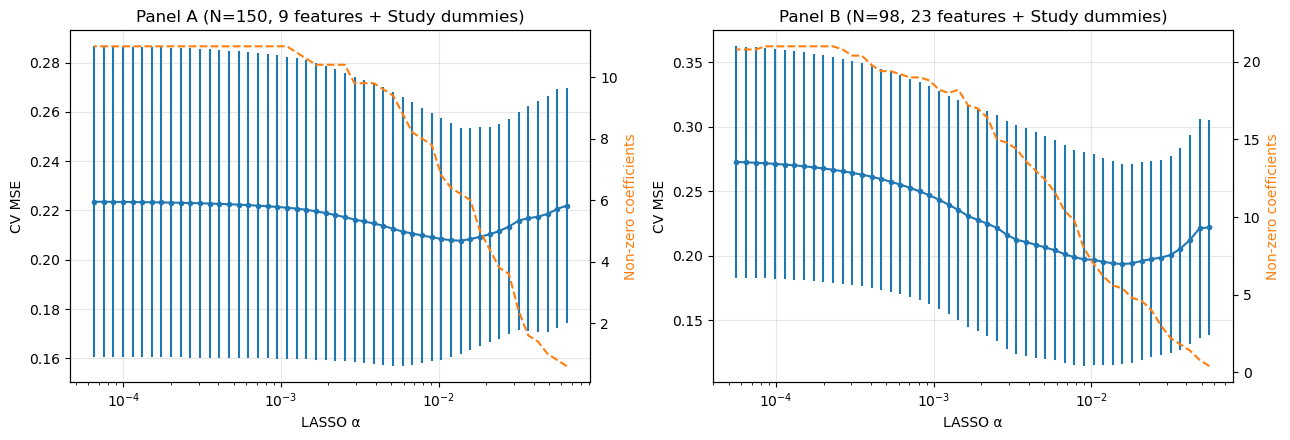

In [8]:
def alpha_path_cv_mse(X, y, n_alphas=50, cv=5, seed=RNG_SEED):
    sc = MinMaxScaler().fit(X)
    Xs = sc.transform(X)
    # Build alpha grid from a quick LassoCV scout
    scout = LassoCV(cv=cv, n_alphas=n_alphas, random_state=seed, max_iter=20000).fit(Xs, y)
    alphas = scout.alphas_
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
    # Use Sex as within-fold stratifier just to keep behavior stable
    strat = np.zeros(len(y), dtype=int)
    mse_grid = np.zeros((len(alphas), cv))
    nnz_grid = np.zeros((len(alphas), cv), dtype=int)
    for k, (tr, te) in enumerate(skf.split(Xs, strat)):
        for j, a in enumerate(alphas):
            m = Lasso(alpha=a, random_state=seed, max_iter=20000)
            m.fit(Xs[tr], y[tr])
            mse_grid[j, k] = mean_squared_error(y[te], m.predict(Xs[te]))
            nnz_grid[j, k] = int(np.sum(m.coef_ != 0))
    return alphas, mse_grid, nnz_grid


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (title, X, y) in zip(axes, [
    ("Panel A (N=150, 9 features + Study dummies)", Xa_with_study.values, ya.values),
    ("Panel B (N=98, 23 features + Study dummies)", Xb_ext.values, yb.values),
]):
    alphas, mse_grid, nnz_grid = alpha_path_cv_mse(X, y)
    mu = mse_grid.mean(axis=1)
    sd = mse_grid.std(axis=1)
    ax.errorbar(alphas, mu, yerr=sd, fmt="-o", markersize=3, color="C0", label="CV MSE ± SD")
    ax.set_xscale("log")
    ax.set_xlabel("LASSO α")
    ax.set_ylabel("CV MSE")
    ax2 = ax.twinx()
    ax2.plot(alphas, nnz_grid.mean(axis=1), "--", color="C1", label="# non-zero coefs")
    ax2.set_ylabel("Non-zero coefficients", color="C1")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("figures/lasso_alpha_vs_mse.pdf", dpi=300)
plt.show()


## 8. Coefficient forest plot — what survives selection?

For each panel: bar chart of pooled-LASSO coefficients with bootstrap 95% CIs.
The talk's "what does the model say is meaningful?" slide.


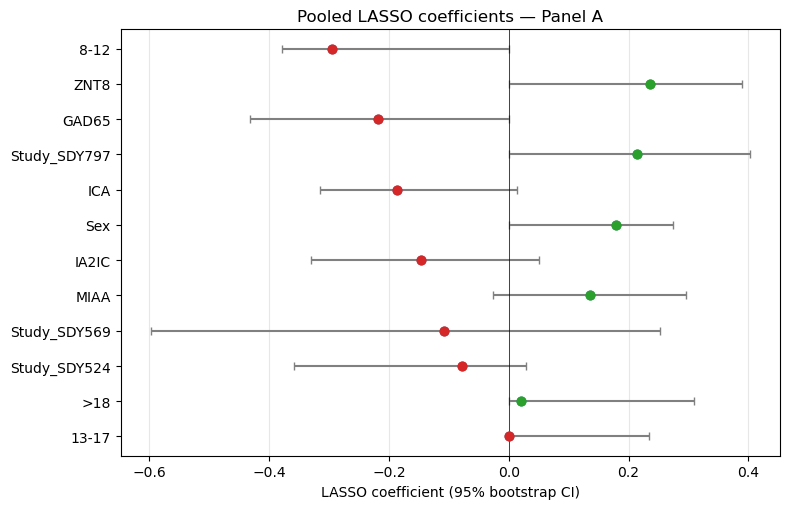

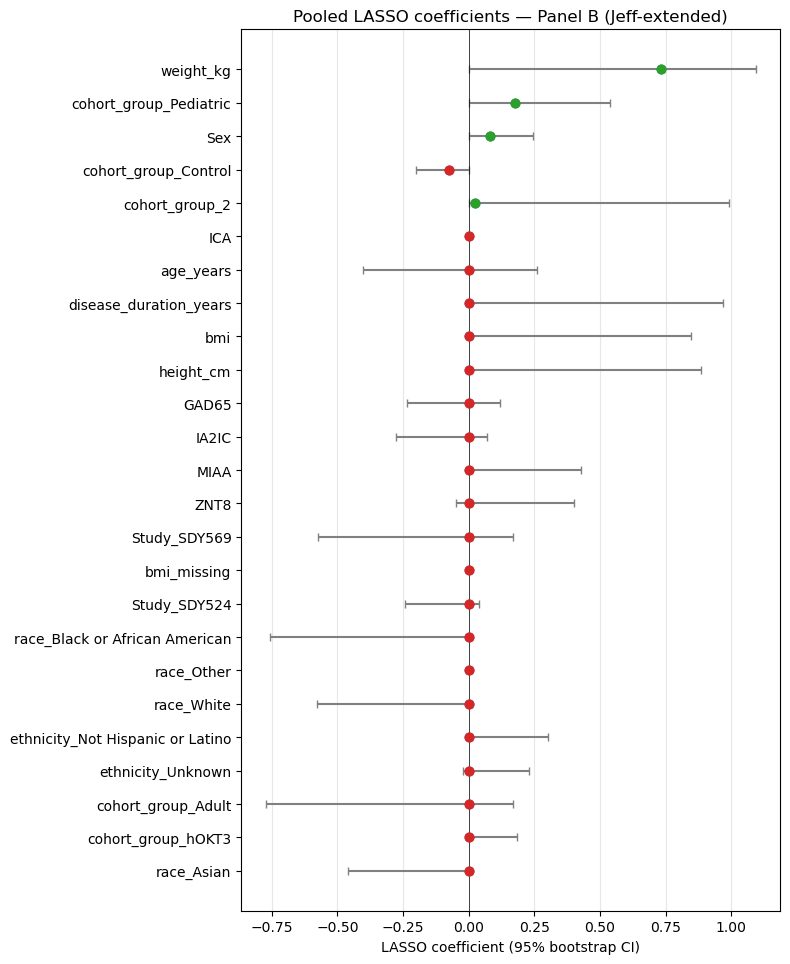

In [9]:
def coef_forest(features, betas, ci_lo, ci_hi, title, savepath):
    order = np.argsort(np.abs(betas))[::-1]
    feats = [features[i] for i in order]
    b = betas[order]
    lo = ci_lo[order]
    hi = ci_hi[order]
    fig, ax = plt.subplots(figsize=(8, 0.35 * len(feats) + 1))
    y_pos = np.arange(len(feats))[::-1]
    err = [b - lo, hi - b]
    colors = ["C2" if x > 0 else "C3" for x in b]
    ax.errorbar(b, y_pos, xerr=err, fmt="o", capsize=3, ecolor="grey")
    for yi, bi, ci in zip(y_pos, b, colors):
        ax.scatter([bi], [yi], color=ci, zorder=10, s=40)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(feats)
    ax.set_xlabel("LASSO coefficient (95% bootstrap CI)")
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.3)
    fig.tight_layout()
    fig.savefig(savepath, dpi=300)
    plt.show()


# Panel A pooled
ci_lo_A = np.percentile(pool_boot, 2.5, axis=0)
ci_hi_A = np.percentile(pool_boot, 97.5, axis=0)
coef_forest(fa_ext, m_pooledA.coef_, ci_lo_A, ci_hi_A,
            "Pooled LASSO coefficients — Panel A",
            "figures/lasso_coefficients_panelA.pdf")

# Panel B pooled — bootstrap there too (slower; 200 reps)
poolB_boot, _ = lasso_bootstrap_coefs(Xb_ext.values, yb.values, n_boot=200)
ci_lo_B = np.percentile(poolB_boot, 2.5, axis=0) if len(poolB_boot) else np.full(len(fb_ext), np.nan)
ci_hi_B = np.percentile(poolB_boot, 97.5, axis=0) if len(poolB_boot) else np.full(len(fb_ext), np.nan)
coef_forest(fb_ext, m_lassoB.coef_, ci_lo_B, ci_hi_B,
            "Pooled LASSO coefficients — Panel B (Jeff-extended)",
            "figures/lasso_coefficients_panelB.pdf")


## 9. CV MSE comparison — adds LASSO/Elastic Net to the head-to-head table

Same stratified-by-Study 5-fold CV protocol as Notebook 1, so these numbers slot
directly into the bake-off table.


In [10]:
def cv_per_fold_mse(model_factory, X, y, study_labels, n_splits=N_FOLDS, seed=RNG_SEED):
    X = np.asarray(X); y = np.asarray(y)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_mse = []
    for tr, te in skf.split(X, study_labels):
        m = model_factory()
        m.fit(X[tr], y[tr])
        fold_mse.append(mean_squared_error(y[te], m.predict(X[te])))
    return np.asarray(fold_mse)


def boot_ci(values, n_boot=N_BOOT, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    boots = np.array([rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_boot)])
    return float(values.mean()), float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))


make_lasso  = lambda: Pipeline([("sc", MinMaxScaler()), ("m", LassoCV(cv=5, random_state=RNG_SEED, max_iter=20000, n_alphas=50))])
make_en     = lambda: Pipeline([("sc", MinMaxScaler()), ("m", ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], cv=5, random_state=RNG_SEED, max_iter=20000, n_alphas=50))])

print("Panel A (with Study dummies):")
mse_lasso_A = cv_per_fold_mse(make_lasso, Xa_with_study.values, ya.values, A["Study"].values)
mse_en_A    = cv_per_fold_mse(make_en,    Xa_with_study.values, ya.values, A["Study"].values)
print(f"  LASSO        per-fold MSE: {mse_lasso_A.round(3)}  mean={mse_lasso_A.mean():.3f}")
print(f"  Elastic Net  per-fold MSE: {mse_en_A.round(3)}  mean={mse_en_A.mean():.3f}")

print("\nPanel B (with Study dummies):")
mse_lasso_B = cv_per_fold_mse(make_lasso, Xb_ext.values, yb.values, B["Study"].values)
mse_en_B    = cv_per_fold_mse(make_en,    Xb_ext.values, yb.values, B["Study"].values)
print(f"  LASSO        per-fold MSE: {mse_lasso_B.round(3)}  mean={mse_lasso_B.mean():.3f}")
print(f"  Elastic Net  per-fold MSE: {mse_en_B.round(3)}  mean={mse_en_B.mean():.3f}")

bake_rows = []
for name, fm, panel in [
    ("LASSO",       mse_lasso_A, "A"),
    ("Elastic Net", mse_en_A,    "A"),
    ("LASSO",       mse_lasso_B, "B"),
    ("Elastic Net", mse_en_B,    "B"),
]:
    mu, lo, hi = boot_ci(fm)
    bake_rows.append({"Model": name, "Panel": panel,
                      "MSE_mean": mu, "MSE_ci_lo": lo, "MSE_ci_hi": hi,
                      "fold_mse": list(map(float, fm))})
bake_df = pd.DataFrame(bake_rows)
print("\n", bake_df.to_string(index=False))
bake_df.drop(columns=["fold_mse"]).to_csv("results/lasso_elasticnet_cv_mse.csv", index=False)
with open("results/lasso_elasticnet_cv_mse_full.json", "w") as f:
    json.dump(bake_rows, f, indent=2)


Panel A (with Study dummies):
  LASSO        per-fold MSE: [0.191 0.263 0.185 0.356 0.149]  mean=0.229
  Elastic Net  per-fold MSE: [0.192 0.231 0.182 0.356 0.147]  mean=0.221

Panel B (with Study dummies):
  LASSO        per-fold MSE: [0.258 0.133 0.074 0.195 0.308]  mean=0.194
  Elastic Net  per-fold MSE: [0.284 0.134 0.074 0.192 0.306]  mean=0.198

       Model Panel  MSE_mean  MSE_ci_lo  MSE_ci_hi                                                                                                 fold_mse
      LASSO     A  0.228809   0.173079   0.300068 [0.19127378530802094, 0.26272307601891404, 0.18507257369694713, 0.3560858257811718, 0.14888838073572008]
Elastic Net     A  0.221438   0.170365   0.290601 [0.19210408856341968, 0.23056121149762912, 0.18175959007722314, 0.3562652155900199, 0.14650151491284816]
      LASSO     B  0.193577   0.120298   0.265433   [0.2578599499284905, 0.13340494024887548, 0.07358569411877405, 0.1946262416147213, 0.3084102016221172]
Elastic Net     B  0.1978

## 10. Outputs

CSVs in `results/`:

- `lasso_local_coefficients_panelA.csv` — per-study LASSO coefs with bootstrap CIs
- `lasso_federated_panelA.csv` — federated (median) coefs + selection consistency
- `lasso_pooled_panelA.csv` — pooled LASSO with Study dummies (Panel A)
- `lasso_pooled_panelB.csv` — pooled LASSO + Elastic Net coefs (Panel B)
- `lasso_stability_{panelA,panelB}.csv` — Meinshausen-Bühlmann selection frequencies
- `lasso_elasticnet_cv_mse.csv` — model bake-off rows for Notebook 3 to consume

Figures in `figures/`:

- `lasso_alpha_vs_mse.pdf` — α-path with MSE and # non-zero coefficients
- `lasso_coefficients_panelA.pdf` — pooled-LASSO forest plot (Panel A)
- `lasso_coefficients_panelB.pdf` — pooled-LASSO forest plot (Panel B)

Continue to **Notebook 3** (`EffectSizes_and_PowerAnalysis_Extended.ipynb`).
